In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import lines
import seaborn as sns
import pandas as pd
import os
from matplotlib.colors import BoundaryNorm, ListedColormap

In [2]:
blue, red, dark = '#00ffff', '#ff0000', '#555555'
dark = '#222222'
sns.set_style('darkgrid')

eps = .1
alpha = .05
ps = {1: 0.08873266197985939, 2: 0.0047332406266393096}
Ns = {1: 23391087.72, 2: 2863668247.4399996}

data_dir = f'eps={eps},alpha={alpha},p1={ps[1]:.4f},p2={ps[2]:.4f},N1={Ns[1]:.0f},N2={Ns[2]:.0f}'

# 3. All simulation trajectories

### Setup

In [4]:
AREA_COL = 'N_dot1'
REPL_COL = 'replication'
ITER_COL = 'iter'

MAX_ITER_COL = 'max_iter'
REV_ITER_COL = 'reverse_iter'
REL_ERR_COL = 'rel_err'

### Read and prepare simulation data

In [5]:
repl_dfs = []
for data_file in os.listdir(data_dir):
    repl = int(data_file.split(os.extsep)[0].split('_')[1])
    repl_df = pd.read_csv(
        os.path.join(data_dir, data_file),
        usecols=[AREA_COL],
        dtype={AREA_COL: "float32"},
    )

    repl_df[REPL_COL] = np.int16(repl)
    repl_dfs.append(repl_df.reset_index(names=ITER_COL))

df = pd.concat(repl_dfs)[[ITER_COL, AREA_COL, REPL_COL]]
df[ITER_COL] = df[ITER_COL].astype("int16")

In [7]:
df[MAX_ITER_COL] = df.groupby(REPL_COL)[ITER_COL].transform('max')
df[REV_ITER_COL] = (df[ITER_COL] - df[MAX_ITER_COL])
df.drop(columns=[ITER_COL, MAX_ITER_COL], inplace=True)

In [8]:
N_dot1 = Ns[1]*(1-ps[1]) + Ns[2]*ps[2]
df[REL_ERR_COL] = np.abs(df[AREA_COL] - N_dot1) / N_dot1
df.drop(columns=[AREA_COL], inplace=True)

### Plot

In [9]:
n_iter = 11500

df = df[df[REV_ITER_COL] > -n_iter]
df.isna().any()

replication     False
reverse_iter    False
rel_err         False
dtype: bool

In [10]:
# Prepare contour data.
x = df[REV_ITER_COL].unique()
n_err_bins = 5000
y = np.linspace(0, df[REL_ERR_COL].max(), n_err_bins)

# Calculate frequencies.
iter_bins = np.arange(-n_iter + 1, 2) - .5
z, *_ = np.histogram2d(df[REV_ITER_COL].values, df[REL_ERR_COL].values,
                       bins=[iter_bins, n_err_bins])
z = z.T

# Calculate relative frequencies.
assert df.groupby(REV_ITER_COL).size().nunique() == 1
n_simulations_per_rev_iter = df.groupby(REV_ITER_COL).size().values
z /= n_simulations_per_rev_iter

# Calculate percentiles.
z = z.cumsum(axis=0)

# Mask values beyond the maximum.
z = np.ma.array(z, mask=np.isclose(z, 1))

/tmp/ipykernel_63132/3201161596.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{float(s):.3g}' for s in ax.get_yticks()])


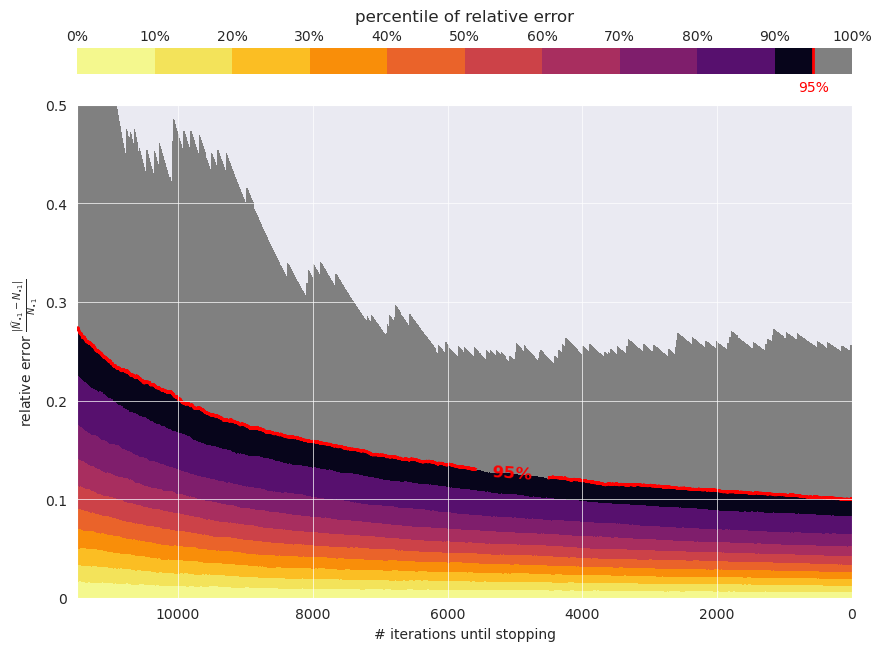

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(False)

# Plot contours.
n_contours = 11

color_levels = list(np.linspace(0, .9, n_contours - 1)) + [.95, 1]

n_bands = len(color_levels) - 1
# Compute each band’s midpoint, normalized to [0,1]
lo, hi = color_levels[0], color_levels[-1]
mid_norm = [
    (0.5 * (color_levels[i] + color_levels[i + 1]) - lo) / (hi - lo)
    for i in range(n_bands)
]
# Sample Inferno at those midpoints
base_colors = plt.cm.inferno(np.array(mid_norm)[::-1])
# Replace the last two bands' colors
base_colors[-1] = [0.5, 0.5, 0.5, 1.0]
base_colors[-2] = (0.025793, 0.019331, 0.10593, 1.0)
# Build a ListedColormap of length 11
my_inferno = ListedColormap(base_colors)

# BoundaryNorm to map each [levels[i], levels[i+1]) → color index i
norm = BoundaryNorm(color_levels, ncolors=n_bands)
# Contours
smooth_scale = 1
cntrs = ax.contourf(x, y, z, levels=color_levels, cmap=my_inferno, norm=norm)

# 5% contour
cntr = ax.contour(x, y, z, [0.95], colors='red', linewidths=2, zorder=667)
ax.clabel(cntr, inline=True, fmt=lambda x: r'$\bf 95\%$', fontsize=12,
          inline_spacing=30, zorder=667, manual=[(-4600, .5)])
          # inline_spacing=30, zorder=667, manual=[(-3600, .5)])

# Colorbar
cbar = plt.colorbar(cntrs, ax=ax, orientation='horizontal', location='top',
                    aspect=30, spacing='proportional')
cbar.set_ticks(color_levels)
cbar.set_ticklabels([f'{prob:.0%}' if prob != .95 else '' for prob in color_levels])
cbar.ax.tick_params(length=0)
# cbar.ax.invert_xaxis()
plt.setp(cbar.ax.spines.values(), visible=False)
cbar.ax.axvline(.95, color='red', lw=2)
cbar.ax.set_title(r'percentile of relative error')
cbar.ax.text(
    0.95, -.25, '95%', transform=cbar.ax.transAxes,
    ha='center', va='top', color='red'
)

# Bound from above at rel.error = 0.5
ax.set_ylim(0, .5)

# Iteration labels and lines
x_ticks = ax.get_xticks()[1:]
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(-int(rev_iter)) for rev_iter in x_ticks], rotation=0)
for x_tick in x_ticks:
    ax.axvline(x_tick, color='w', lw=.5, zorder=999)

# Relative error lines
y_ticks = ax.get_yticks()[1:]
ax.set_yticklabels([f'{float(s):.3g}' for s in ax.get_yticks()])
for y_tick in ax.get_yticks():
    ax.axhline(y_tick, color='w', lw=.5, zorder=999)

ax.set_xlabel('# iterations until stopping')
ax.set_ylabel(r'relative error $\frac{|\widehat{N}_{\bullet 1} - N_{\bullet 1}|}{N_{\bullet 1}}$')

plt.savefig(f'3_rel_error_trajectories.png', bbox_inches='tight', dpi=600)

In [12]:
df[df[REV_ITER_COL] == 0][REL_ERR_COL].quantile(.95)

np.float64(0.10058066315594259)